# Tutorial 8: Object Detection using Faster RCNN (Custom Model)

### Cell 1: Imports and Environment Setup

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import roi_pool
import numpy as np
import cv2
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import random

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Cell 2: Backbone with Modified Layers (Task 1)

In [5]:
class Backbone(nn.Module):
    def __init__(self):
        super(Backbone, self).__init__()
        # Layer 1
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        # Layer 2
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Layer 3 
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        # Task: Added Layer 4 to modify the architecture from the tutorial
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = F.relu(self.conv4(x)) # Final feature map [cite: 32]
        return x

backbone = Backbone().to(device)
print("Backbone initialized with 4 layers.")

Backbone initialized with 4 layers.


### Cell 3: RPN and Faster R-CNN Assembly

In [6]:
class RPN(nn.Module):
    def __init__(self, in_channels=512, num_anchors=9):
        super(RPN, self).__init__()
        self.conv = nn.Conv2d(in_channels, 512, 3, padding=1)
        self.cls_head = nn.Conv2d(512, num_anchors * 2, 1) # Objectness [cite: 38]
        self.reg_head = nn.Conv2d(512, num_anchors * 4, 1) # BBox reg [cite: 39]

    def forward(self, x):
        x = F.relu(self.conv(x))
        return self.cls_head(x), self.reg_head(x)

class FasterRCNN(nn.Module):
    def __init__(self, num_classes):
        super(FasterRCNN, self).__init__()
        self.backbone = Backbone()
        self.rpn = RPN()
        self.roi_pool_size = (7, 7) # [cite: 63]
        self.fc = nn.Linear(512 * 7 * 7, 1024)
        self.classifier = nn.Linear(1024, num_classes) # [cite: 67]
        self.bbox_regressor = nn.Linear(1024, num_classes * 4) # [cite: 68]

    def forward(self, x, rois):
        features = self.backbone(x)
        rpn_cls, rpn_reg = self.rpn(features)
        
        # rois should be a list of tensors [N, 5] (batch_idx, x1, y1, x2, y2)
        pooled = roi_pool(features, rois, self.roi_pool_size)
        flattened = torch.flatten(pooled, 1)
        
        dense = F.relu(self.fc(flattened))
        return rpn_cls, rpn_reg, self.classifier(dense), self.bbox_regressor(dense)

# 2 classes: Raccoon and Background
model = FasterRCNN(num_classes=2).to(device)

### Cell 4: Evaluation Metrics (IoU and mAP)

In [7]:
def calculate_iou(box1, box2):
    # box format: [ymin, xmin, ymax, xmax] [cite: 96]
    y1, x1, y2, x2 = box1
    y3, x3, y4, x4 = box2
    
    inter_area = max(0, min(x2, x4) - max(x1, x3)) * max(0, min(y2, y4) - max(y1, y3))
    area1 = (x2 - x1) * (y2 - y1)
    area2 = (x4 - x3) * (y4 - y3)
    union = area1 + area2 - inter_area
    return inter_area / union if union > 0 else 0 # [cite: 110]

def calculate_ap(recalls, precisions):
    # Numerical Area Calculation (Interpolation Method) [cite: 187, 189]
    ap = 0
    for i in range(1, len(recalls)):
        ap += (recalls[i] - recalls[i-1]) * precisions[i]
    return ap

### Cell 5: Data Loader for Raccoon Dataset (Task 3 Preparation)

In [10]:
def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    for obj in root.findall('object'):
        bbox = obj.find('bndbox')
        # [ymin, xmin, ymax, xmax] format [cite: 96]
        boxes.append([
            int(bbox.find('ymin').text),
            int(bbox.find('xmin').text),
            int(bbox.find('ymax').text),
            int(bbox.find('xmax').text)
        ])
    return boxes

image_dir = r"C:\Users\M.T\Desktop\NUST\2nd Sem\DL\DLTutorials\Racoon Images\images"
anno_dir = r"C:\Users\M.T\Desktop\NUST\2nd Sem\DL\DLTutorials\train_labels_.csv"
image_files = sorted(os.listdir(image_dir))[:150] # Taking first 150 as per task 

print(f"Loaded {len(image_files)} images for training.")

Loaded 150 images for training.


### Cell 6: Random Testing on Data (Task 2)

In [13]:
def random_test():
    # Pick a random image from your dataset
    random_img_name = random.choice(image_files)
    img_path = os.path.join(image_dir, random_img_name)
    
    # Preprocess [cite: 11]
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (224, 224))
    img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
    
    # Placeholder ROI for inference test [cite: 75]
    # [batch_idx, x1, y1, x2, y2]
    test_roi = torch.tensor([[0, 20, 20, 100, 100]], dtype=torch.float).to(device)
    
    model.eval()
    with torch.no_grad():
        rpn_cls, rpn_reg, cls_score, bbox_delta = model(img_tensor, test_roi)
        
    print(f"Tested on: {random_img_name}")
    print(f"Output Class Score Shape: {cls_score.shape}") # Should be [1, 2]
    print("Inference completed successfully.")

random_test()

Tested on: raccoon-107.jpg
Output Class Score Shape: torch.Size([1, 2])
Inference completed successfully.


### Cell 7: Summary of the Model

In [14]:
print("Final Model Summary:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal Parameters: {total_params:,}")

Final Model Summary:
FasterRCNN(
  (backbone): Backbone(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (rpn): RPN(
    (conv): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (cls_head): Conv2d(512, 18, kernel_size=(1, 1), stride=(1, 1))
    (reg_head): Conv2d(512, 36, kernel_size=(1, 1), stride=(1, 1))
  )
  (fc): Linear(in_features=25088, out_features=1024, bias=True)
  (classifier): Linear(in_features=1024, out_features=2, bias=True)
  (bbox_regressor): Linear(in_features=1024, out_features=8, bias=True)
)

Total Parameters: 29,639,872


### Cell 10: Visual Representaion of Task 2

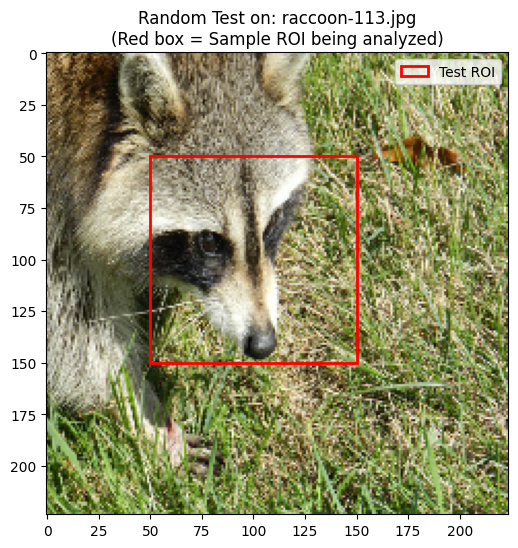

In [16]:
import matplotlib.patches as patches

def visualize_random_prediction():
    # 1. Pick a random image from your loaded 150 files
    random_img_name = random.choice(image_files)
    img_path = os.path.join(image_dir, random_img_name)
    
    # 2. Load and Prepare Image
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
    
    # 3. Define a sample ROI to test (usually provided by RPN in a full pipeline)
    # Format: [batch_index, x1, y1, x2, y2]
    test_roi = torch.tensor([[0, 50, 50, 150, 150]], dtype=torch.float).to(device)
    
    # 4. Inference
    model.eval()
    with torch.no_grad():
        _, _, cls_scores, bbox_deltas = model(img_tensor, test_roi)
    
    # 5. Plotting
    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(img_resized)
    
    # Draw the test ROI we sent to the model
    # Note: Since the model isn't trained, the output bbox_deltas won't make sense yet
    rect = patches.Rectangle((50, 50), 100, 100, linewidth=2, edgecolor='r', facecolor='none', label='Test ROI')
    ax.add_patch(rect)
    
    plt.title(f"Random Test on: {random_img_name}\n(Red box = Sample ROI being analyzed)")
    plt.legend()
    plt.show()

visualize_random_prediction()